In [1]:
# Visualization of severity distribution across different manufacturers and trigger mechanisms

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# =========================
# Load dataset
# =========================
df = pd.read_excel("data/dataframe_processed.xlsx")

# Ensure severity is categorical
df['Severity'] = df['Severity'].astype('category')

# =========================
# Helper function: create proportion table
# =========================
def proportion_table(df, category_col):
    pivot = (
        df.groupby([category_col, "Severity"])
        .size()
        .groupby(level=0)
        .apply(lambda x: x / x.sum())
        .unstack()
        .fillna(0)
    )
    return pivot

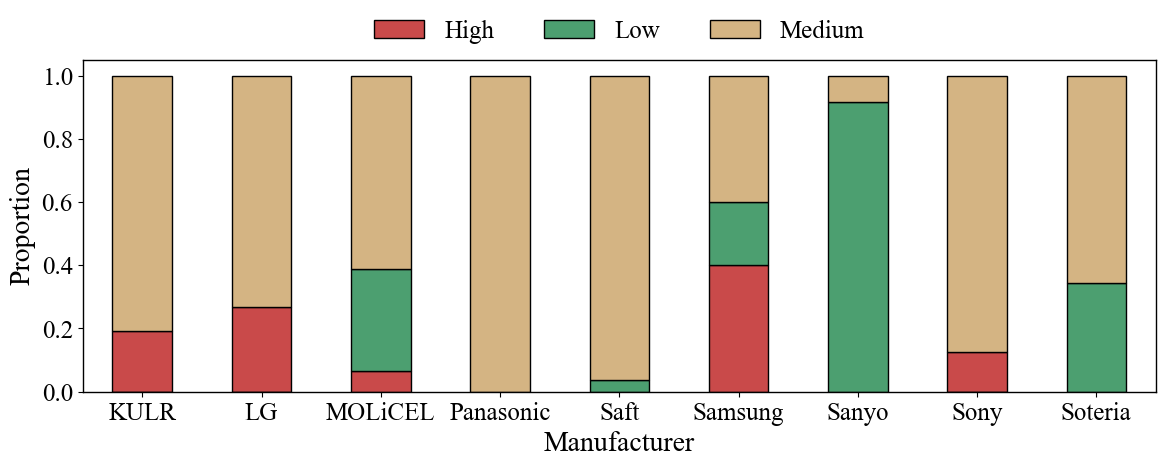

In [2]:
colors = {
    "Low": "#4C9F70",      # muted green (safe, stable)
    "Medium": "#D4B483",   # desaturated sand / khaki
    "High": "#C94A4A",     # muted red (hazard, not aggressive)
}

# Global font and plot settings
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "axes.linewidth": 1.0
})


# =========================
# Figure 1: Manufacturer × Severity proportion bar plot
# =========================
fig, ax = plt.subplots(figsize=(12, 5))

pivot_manu = proportion_table(df, "Manufacturer")

pivot_manu.index = pivot_manu.index.map(
    lambda x: x[0] if isinstance(x, tuple) else x
)

pivot_manu.plot(
    kind="bar",
    stacked=True,
    color=[colors[col] for col in pivot_manu.columns],
    ax=ax,
    edgecolor="black",
    linewidth=1.0                       
)

ax.set_ylabel("Proportion")
ax.set_xlabel("Manufacturer")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.legend(
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig(
    "imgs/plot/Severity_Distribution_by_Manufacturer.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

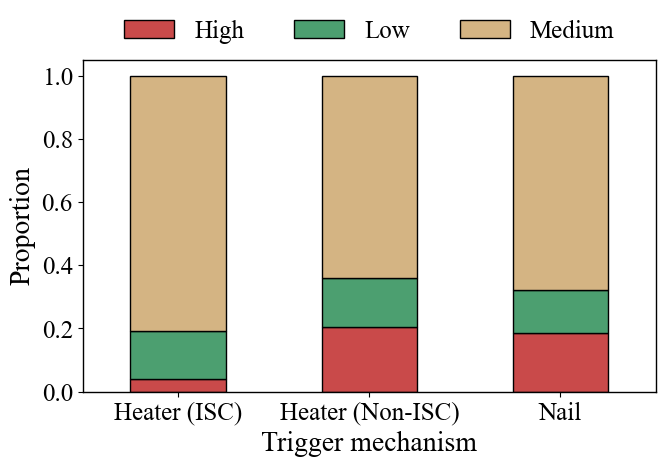

In [3]:
# =========================
# Figure 2: Trigger Mechanism × Severity proportion bar plot
# =========================
fig, ax = plt.subplots(figsize=(7, 5))

pivot_trigger = proportion_table(df, "Trigger-Mechanism")

pivot_trigger.index = pivot_trigger.index.map(
    lambda x: x[0] if isinstance(x, tuple) else x
)

pivot_trigger.plot(
    kind="bar",
    stacked=True,
    color=[colors[col] for col in pivot_trigger.columns],
    ax=ax,
    edgecolor="black",
    linewidth=1.0    
)

ax.set_ylabel("Proportion")
ax.set_xlabel("Trigger mechanism")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

ax.legend(
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.savefig(
    "imgs/plot/Severity_Distribution_by_Trigger_Mechanism.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()
